In [144]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 
from toqito.channels import partial_trace

In [3]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)


def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod
    
# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q   
    return q

""" TO DO
check the difference between this function and x=unitary_group.rvs(3)
and the Gaussian unitary ensemble
"""


def mkLiouvillian(rate, dt, ldbldOp): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    # print(np.allclose(G, G.T.conj()) )
    denseU=linalg.expm( (-1j*H + G) * dt)
    
    return denseU # to act on the vectorized density matrix of 2 qubits

def mkKrausOps(U): 
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))   
    [eigVals, eigVecs] = linalg.eigh(X)
    
    krausOps=[]
    
    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.csr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]
            
    return krausOps


def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    
    k_abs=np.array([[] for i in range(16)],dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4),dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    return k_abs


In [4]:
# at layers where PBC is not needed
def mkGlobalKrausOps(layer, Nqubit, rate, dt, ldbldOp, debug=True):
    
    allKs = {}

    if np.mod(layer,2) == 0:    
        # position records the site with the non-trivial unitary
        
        positions = [i for i in range(0, Nqubit-1, 2)]
        
        for pos in positions:
            
            # one needs to make N/2 different random unitaries        
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))
        
        for pos in positions:  
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp))
            allKs[pos] = []
            
            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]
                    
            else:
                # decomposition of Kraus is required with PBC
                
                k_abs = decompKrausOps(krausOps)
                
                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):  
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128') 
                        U_chain[pos] = paulis[basisInd//4] 
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)] 

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]   

    return allKs

In [52]:
# employ the faster Kraus Unitary sum
def evolveKrausU(allKs, rho):
    
    Nqubit = int(np.log2(len(rho.toarray())))
 
    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()   
            
            #if debug == True:
            #    print(np.trace(newRho.toarray()))
        
    return newRho


# make measurement  (something is wrong with this thing)
"""TO DO
what on earth is that error???? or in the entanglement entropy computation
"""
def mkS_zMsm(probMsm, rho):
    
    Nqubit = int(np.log2(len(rho.toarray())))
    sites = [n for n in range(Nqubit)]
    randomNumbers = np.random.uniform(0,1,Nqubit)
    msmSites = np.where(randomNumbers < probMsm)[0]

    if list(msmSites) !=[]:

        Projs = [
            (np.eye(2)+S_Z)/2, 
            (np.eye(2)+(-1)*S_Z)/2
        ]

        numMsSites=len(msmSites)
        #print(msmSites)
        
        # make one projection msm at a time:
        for (j,ms) in enumerate(msmSites):  
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[0]
            proj0p = reduce(sparse.kron, proj_chain)
            
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[1]
            proj1p = reduce(sparse.kron, proj_chain)

            # probability of having one of the outcomes
            prob = np.trace((proj0p @ rho @ proj0p.T.conj()).toarray())
            if np.random.random(1) < prob:
                testRho = (proj0p @ rho @ proj0p.T.conj())/prob
                
            else:
                testRho = (proj1p @ rho @ proj1p.T.conj())/(1-prob)

            ## check if the other prob is complementary
            #prob1 = np.trace((proj1p@rho@proj1p.T.conj()).toarray())
            #print(prob+prob1)

            # One needs to keep track of the measurement!!!
            rho = testRho

    else:
        testRho = rho

    return testRho 


In [44]:
def calcS(densityM, partiesToTraceOut=[1]):
    Ntot=int(np.log2(densityM.shape[0]))
    redRho = partial_trace(densityM, partiesToTraceOut, [2]* Ntot)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S

def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity
    

In [45]:
import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep',style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [59]:
def ensSAvgroutine(N_ens, Nqubit, probMsm, steps):
        
    ensembleS = np.zeros([rep,steps])
    
    state0 = (qb[0] + qb[1])/np.sqrt(2)
    state0rho = np.outer(state0, state0)

    for e in range(N_ens):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))
        for s in range(steps):
            allKrausOps = mkGlobalKrausOps(s, Nqubit, 0, 5, S_Z, debug=False)
            rho = evolveKrausU(allKrausOps, rho)
            rho = mkS_zMsm(probMsm, rho)
            #print(calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2))))
            ensembleS[e,s] = calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2)))

    ensAvg = np.average(ensembleS ,axis=0)
            
    return ensAvg


In [68]:
ensSAvgroutine(N_ens=2, Nqubit=4, probMsm=0.001, steps=50)

array([0.06172305, 0.06519741, 0.06112756, 0.07279796, 0.08115941,
       0.07829175, 0.07954162, 0.08550213, 0.08286061, 0.07354184,
       0.06580984, 0.08155864, 0.08512559, 0.07902378, 0.07536372,
       0.08729821, 0.09538396, 0.08662589, 0.08658716, 0.08427924,
       0.08578953, 0.07015734, 0.08157474, 0.07832484, 0.09082969,
       0.09250411, 0.08989296, 0.08126135, 0.09167418, 0.08633079,
       0.09053926, 0.08383215, 0.08866942, 0.08123415, 0.08932049,
       0.09229147, 0.08770725, 0.06826678, 0.09536291, 0.0907385 ,
       0.08208363, 0.07969798, 0.07109897, 0.08489917, 0.08512982,
       0.07922557, 0.0761641 , 0.06870449, 0.08450655, 0.08708347])

In [66]:
avgedS_dynamics

{0: {4: array([0.39174021, 0.68372072]),
  6: array([5.99841613e-15, 1.40006395e+00]),
  8: array([0.35357635, 1.19114422]),
  10: array([6.91940125e-15, 1.48527854e+00])},
 0.01: {4: array([0.27255935, 0.68971281])}}

In [67]:
avgedS_steady

{0: array([0.68372072, 1.40006395, 1.19114422, 1.48527854]),
 0.01: array([0.68971281, 0.        , 0.        , 0.        ])}

In [69]:
# figure out p_c, without dephasing. should be .16

# p_c with 4 data points ha, ha
NList = [4, 6, 8, 10]
probList = [0, 0.01, 0.05, 0.1, 0.15, 0.2, .3, .4]


# pure state start
qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)

t_total = 200
rep = 20 
dt = 5

steps = int(t_total/dt)


avgedS_dynamics = {}
avgedS_steady = {}

for probMsm in probList:
    
    avgedS_dynamics[probMsm] = {}
    avgedS_steady[probMsm] = np.zeros(len(NList))
    
    startTime = time.time()
    
    print('probMsm=',probMsm)
    
    for (ind, N) in enumerate(NList):
        
        avgedS_dynamics[probMsm][N] = ensSAvgroutine(rep, N, probMsm, steps)    
        avgedS_steady[probMsm][ind] = np.average(avgedS_dynamics[probMsm][N][steps//2:])
    
    print(time.time()-startTime)



probMsm= 0
571.7270538806915
probMsm= 0.01
742.0305299758911
probMsm= 0.05
937.16157579422
probMsm= 0.1
1227.5219719409943
probMsm= 0.15
1335.8502037525177
probMsm= 0.2
1504.3809790611267
probMsm= 0.3
1834.175579071045
probMsm= 0.4
2179.4609956741333


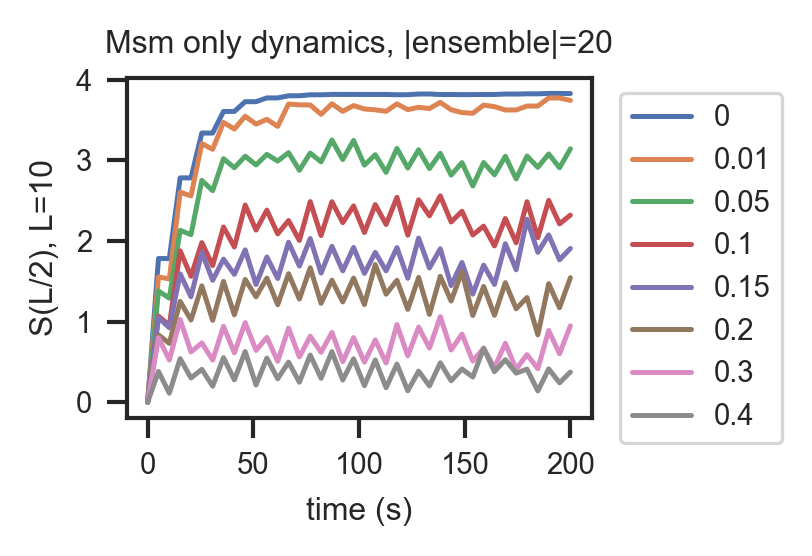

In [79]:
duration = np.linspace(0,t_total,int(t_total/dt))

for (j,prob) in enumerate(probList):
    plt.plot(duration, avgedS_dynamics[prob][10]) 
plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=10')
plt.title('Msm only dynamics, |ensemble|=20')
plt.legend(probList,bbox_to_anchor= (1.03, 1) )


In [77]:
probList

[0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]

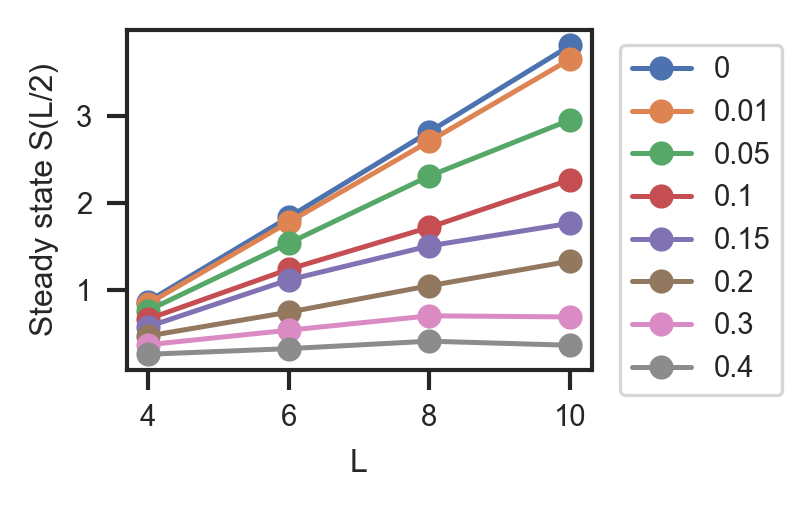

In [156]:
plt.figure()
for probMsm in probList:
    plt.plot(np.array(NList).astype(float), np.array(avgedS_steady[probMsm]).astype(float),'o-')
plt.xlabel('L')
plt.ylabel(r'Steady state S(L/2)')
plt.legend(probList,bbox_to_anchor= (1.03, 1) )

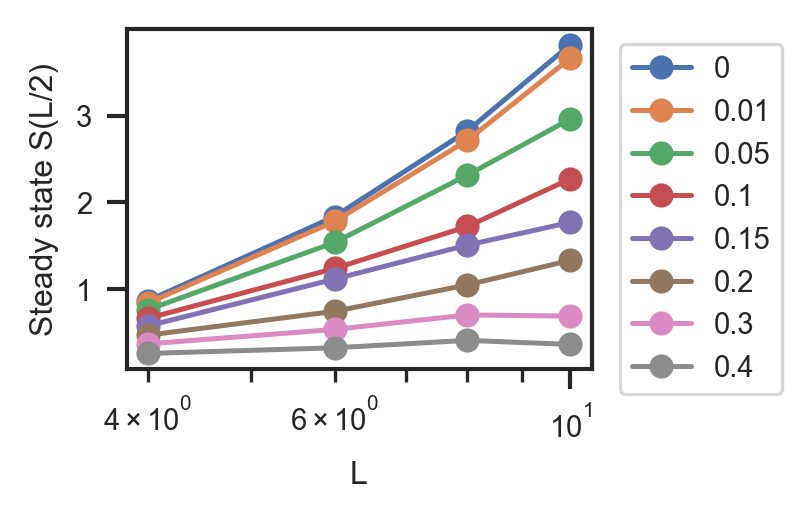

In [157]:
plt.figure()
for probMsm in probList:
    plt.semilogx(np.array(NList).astype(float), np.array(avgedS_steady[probMsm]).astype(float),'o-')
plt.xlabel('L')
plt.ylabel(r'Steady state S(L/2)')
plt.legend(probList,bbox_to_anchor= (1.03, 1) )

In [ ]:
# collapse the data fig 13(b)
# collapse with nonzero gamma (gamma =0, 0.1, 1, 100)
# sigma_z should be less interesting
# sigma_- would be interesting because 

In [85]:
avgedS_steady

{0: array([0.85899739, 1.83344092, 2.8229532 , 3.81935004]),
 0.01: array([0.83318946, 1.77744318, 2.71368031, 3.66215238]),
 0.05: array([0.7558431 , 1.53407598, 2.31209238, 2.96002972]),
 0.1: array([0.65717767, 1.2336211 , 1.71828451, 2.26869675]),
 0.15: array([0.56913637, 1.11113952, 1.50409687, 1.76578917]),
 0.2: array([0.46283919, 0.73820583, 1.04373905, 1.32794278]),
 0.3: array([0.3619542 , 0.52984801, 0.69642827, 0.68329917]),
 0.4: array([0.2516432 , 0.31706946, 0.4031318 , 0.35612087])}

In [107]:
avgedS_inN={}
for (ind, N) in enumerate(NList):
    avgedS_inN[N] = np.zeros(8)
    i = 0 
    for probMsm in probList:
        avgedS_inN[N][i] = avgedS_steady[probMsm][ind]
        i +=1

1.3153579715555976 -1.2485125433937478


Text(0, 0.5, '$S(A/2)/L^{\\gamma}$')

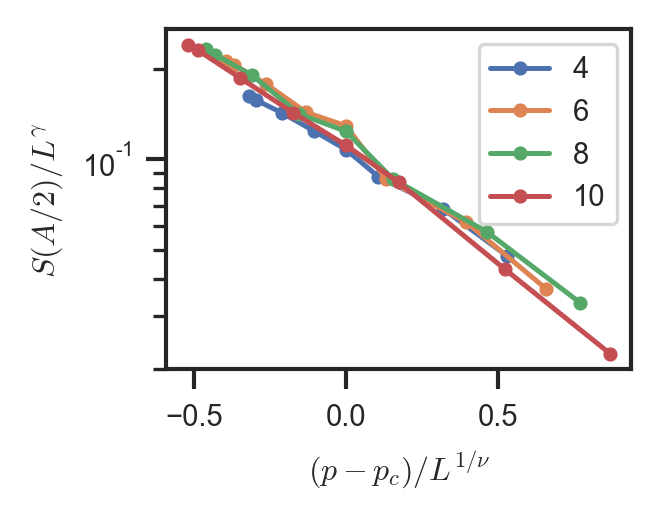

In [154]:
#plt.figure()
#plt.semilogx(np.array(NList).astype(float), np.array(avgedS_steady[0.15]).astype(float),'o-')
[alpha_p, intercept] = np.polyfit(np.log(NList), np.array(avgedS_steady[0.15]).astype(float), 1)
print(alpha_p, intercept)
#dom = np.linspace(NList[0],NList[-1])
#plt.semilogx(dom, alpha_p * np.log(dom) + intercept)
#plt.xlabel(r'$|A|$')
#plt.ylabel(r'S(A/2)')


# Assume no finite size effect even tho there clearly is
plt.figure()

# Spoz the following:
p_c = 0.15 # matched with Clifford
nu = 1.85 # matched-ish with Clifford
gamma = 1.2 # different from Clifford
for N in NList:
    orderParam = (np.array(probList) - p_c) * N ** (1/nu)
    plt.semilogy(orderParam, avgedS_inN[N] / N ** gamma ,'.-')
    
plt.legend(NList)

plt.xlabel(r'$(p-p_c)/L^{1/\nu}$')
plt.ylabel(r'$S(A/2)/L^{\gamma}$')


In [ ]:
# Try Clifford group, subsystem size = L/4

# from PhysRevB.98.205136:
CNOT_L = 1/2 * (np.eye(2) + S_Z) + (1 - S_Z)@S_X
CNOT_R = 1/2 * (np.eye(2) + S_Z) + np.kron(S_X, (1 - S_Z))
H = 1/np.sqrt(2) *(S_X + S_Z)
P = linalg.sqrtm()

cliffGroup=[]

def mkCliffordU(rate, dt, ldbldOp): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    # print(np.allclose(G, G.T.conj()) )
    denseU=linalg.expm( (-1j*H + G) * dt)
    
    return denseU # to act on the vectorized density matrix of 2 qubits
